# Comparativo entre dados

## Importando bibliotecas

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

## Coleta de resultados

In [15]:
FOLDER = "../output_detection"
all_data = []

if not os.path.exists(FOLDER):
    print(f"ERRO: Pasta {FOLDER} não encontrada.")
else:
    files = [f for f in os.listdir(FOLDER) if f.endswith('.csv')]
    
    for file in files:
        date_match = re.search(r'(\d{2}-\d{2}-\d{4})', file)
        if date_match:
            date_str = date_match.group(1)
            df_temp = pd.read_csv(os.path.join(FOLDER, file))
            
            context_cols = [col for col in df_temp.columns if col not in ['name', 'rank']]
            
            stats = (df_temp[context_cols].mean() * 100).to_dict()
            stats['Data'] = date_str
            stats['Total_Analizado'] = len(df_temp)
            
            all_data.append(stats)

    df_comparison = pd.DataFrame(all_data)
    df_comparison['Data'] = pd.to_datetime(df_comparison['Data'], format='%d-%m-%Y')
    df_comparison = df_comparison.sort_values('Data')
    
    print(f"Encontrados {len(df_comparison)} pontos temporais para comparação.")
    display(df_comparison)

Encontrados 3 pontos temporais para comparação.


,AGENTS.md,CLAUDE.md,COPILOT,GEMINI.md,CURSOR,Data,Total_Analizado
2,29.0,22.0,15.0,3.0,0.0,2025-08-24,100
0,30.0,23.0,15.0,2.0,0.0,2026-03-23,100
1,30.0,23.0,15.0,3.0,0.0,2026-04-01,100


## Análises

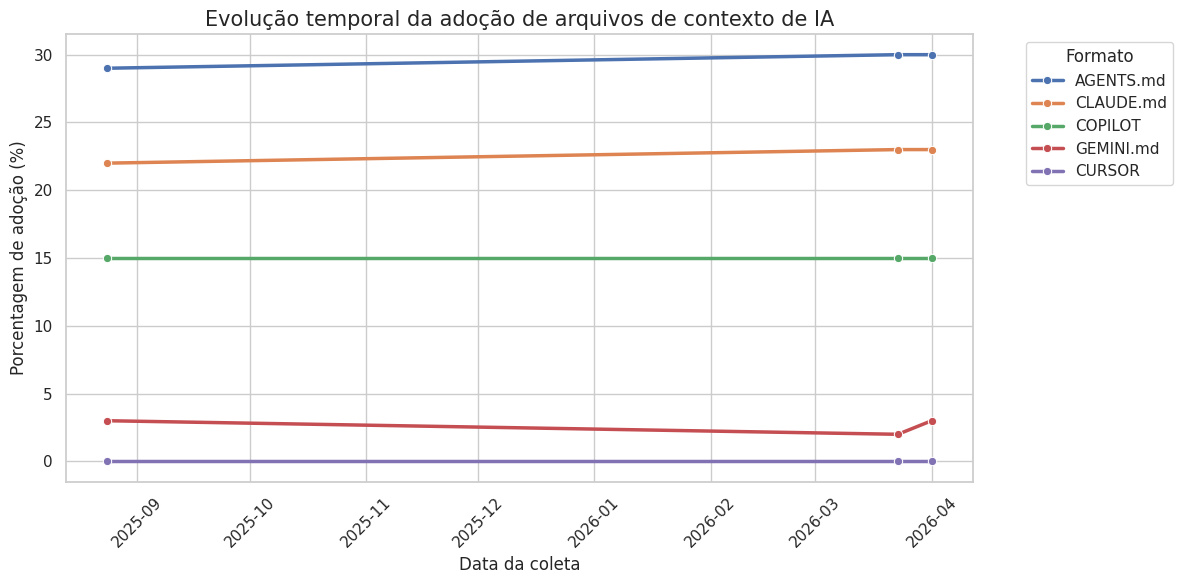

In [16]:
df_melted = df_comparison.melt(id_vars=['Data', 'Total_Analizado'], 
                               var_name='Formato', 
                               value_name='Porcentagem')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, x='Data', y='Porcentagem', hue='Formato', marker='o', linewidth=2.5)

plt.title("Evolução temporal da adoção de arquivos de contexto de IA", fontsize=15)
plt.ylabel("Porcentagem de adoção (%)")
plt.xlabel("Data da coleta")
plt.xticks(rotation=45)
plt.legend(title="Formato", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Comparação entre a coleta mais antiga vs mais recente

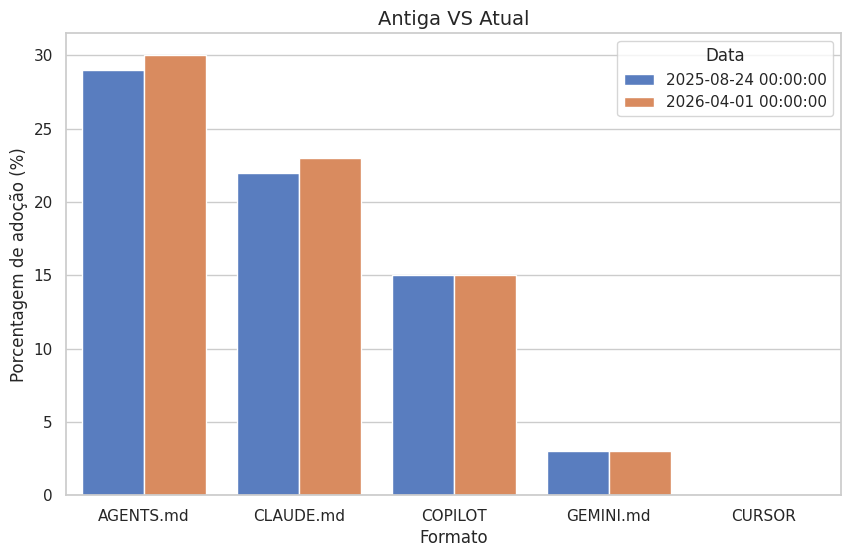

In [14]:
if len(df_comparison) >= 2:
    first_last = df_comparison.iloc[[0, -1]]
    fl_melted = first_last.melt(id_vars=['Data'], var_name='Formato', value_name='Porcentagem')
    fl_melted = fl_melted[fl_melted['Formato'] != 'Total_Analizado']
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=fl_melted, x='Formato', y='Porcentagem', hue='Data', palette="muted")
    
    plt.title("Antiga VS Atual", fontsize=14)
    plt.ylabel("Porcentagem de adoção (%)")
    plt.show()
else:
    print("Necessário pelo menos 2 arquivos com datas diferentes para esta comparação.")